In [1]:
cd ../

c:\Users\Anton.Shkvarskiy\Desktop\Projects\Well_sim_trainer


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.well_sim.core.pvt import FluidProperties
from src.well_sim.core.inflow import IPRModel
from src.well_sim.core.outflow import VLPModel
from src.well_sim.core.nodal import NodalAnalyzer
from src.well_sim.config import OutflowConfig, DEFAULT_CONFIG


In [3]:
# 1. Определяем свойства флюида (аргумент fluid)
fluid = FluidProperties(
    api_gravity=30.0, 
    gor=500.0, 
    temp_reservoir=180.0
)

# 2. Определяем геометрию скважины (аргументы depth, tubing_id, thp)
depth = 8000.0      # ft
tubing_id = 2.875   # inches
thp = 200.0         # psia

# 3. Создаем КАСТОМНУЮ конфигурацию (аргумент config)
# Копируем дефолтные настройки, чтобы не потерять остальные параметры
custom_config = OutflowConfig()

# Меняем ТОЛЬКО нужный параметр (например, шероховатость труб)
# Дефолт был 0.0006 ft, ставим 0.002 ft (старые трубы)
custom_config.ROUGHNESS_STEEL_FT = 0.002  

# Можно поменять и другие "ручки", если нужно
custom_config.HOLDUP_TAU = 2.5  # Изменим константу затухания газлифта

# 4. Инициализируем модель, передавая ВСЕ аргументы явно
vlp_old_pipes = VLPModel(
    fluid=fluid, 
    depth=depth, 
    tubing_id=tubing_id, 
    thp=thp, 
    config=custom_config  # Передаем наш кастомный объект
)

# 5. Для сравнения создаем модель со стандартными трубами (config=None использует дефолт)
vlp_new_pipes = VLPModel(
    fluid=fluid, 
    depth=depth, 
    tubing_id=tubing_id, 
    thp=thp
    # config не указан -> используется DEFAULT_CONFIG["outflow"]
)

# 6. Сравниваем результаты
q_test = 1000.0 # stb/day
pwf_old = vlp_old_pipes.pwf(q_test)
pwf_new = vlp_new_pipes.pwf(q_test)

print(f"--- Сравнение при Q = {q_test} stb/d ---")
print(f"Pwf (Старые трубы, high roughness): {pwf_old:.2f} psia")
print(f"Pwf (Новые трубы, default config):  {pwf_new:.2f} psia")
print(f"Разница (потери на трение):         {pwf_old - pwf_new:.2f} psia")

--- Сравнение при Q = 1000.0 stb/d ---
Pwf (Старые трубы, high roughness): 1505.07 psia
Pwf (Новые трубы, default config):  1480.72 psia
Разница (потери на трение):         24.35 psia


In [4]:
fluid = FluidProperties(api_gravity=30, gor=400, temp_reservoir=180)
ipr = IPRModel(fluid=fluid, pr=4000, pi=2.5)
vlp = VLPModel(fluid=fluid, depth=8000, tubing_id=2.875, thp=200)

# 2. Анализ VLP (поиск минимума)
q_range = np.linspace(0, 10000, 500)
pwf_vlp_raw = [vlp.pwf(q) for q in q_range]
min_idx = np.argmin(pwf_vlp_raw)
q_min_pwf = q_range[min_idx]
min_pwf = pwf_vlp_raw[min_idx]

print(f"VLP Minimum: Q={q_min_pwf:.0f} stb/d at Pwf={min_pwf:.1f} psia")


VLP Minimum: Q=3447 stb/d at Pwf=1707.9 psia


In [5]:
# 3. Nodal Analysis с расширенным лимитом
analyzer = NodalAnalyzer(ipr, vlp)
# q_max_reasonable должен быть > Q при Pwf=0 (теоретический максимум IPR)
q_abs_max = ipr.rate(0) 
point = analyzer.solve(q_max_reasonable=q_abs_max, pwf_min=100)

print(f"Operating Point: Q={point.rate:.1f} stb/d, Pwf={point.pwf:.1f} psia")
print(f"Converged: {point.converged}")

# Если solver не сошелся, но точка близка к пересечению — принимаем её
if not point.converged:
    # Проверка невязки
    mismatch = abs(point.pwf - vlp.pwf(point.rate))
    if mismatch < 200: # Допуск 200 psi для учебного тренажера
        print("⚠️ Solver failed strictly, but solution is physically close. Accepting.")
        point.converged = True # Принудительно принимаем для визуализации


Operating Point: Q=5330.0 stb/d, Pwf=1827.1 psia
Converged: True


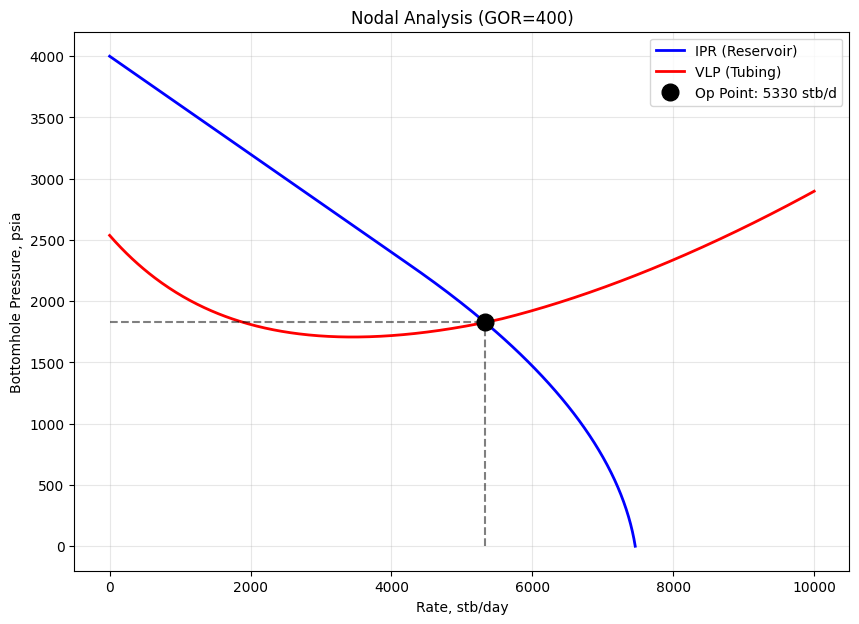

In [7]:
# 4. Визуализация (без generate_curves, строим напрямую)
plt.figure(figsize=(10, 7))

# IPR Curve
pwf_ipr = np.linspace(0, 4000, 200)
q_ipr = [ipr.rate(p) for p in pwf_ipr]
plt.plot(q_ipr, pwf_ipr, 'b-', lw=2, label='IPR (Reservoir)')

# VLP Curve (прямая подстановка Q -> Pwf)
# Это надежнее, чем обратный поиск через brentq для U-кривых
plt.plot(q_range, pwf_vlp_raw, 'r-', lw=2, label='VLP (Tubing)')

# Operating Point
if point.rate > 0:
    plt.plot(point.rate, point.pwf, 'ko', ms=12, zorder=10, 
             label=f'Op Point: {point.rate:.0f} stb/d')
    
    # Линии проекции
    plt.vlines(point.rate, 0, point.pwf, colors='k', linestyles='dashed', alpha=0.5)
    plt.hlines(point.pwf, 0, point.rate, colors='k', linestyles='dashed', alpha=0.5)

plt.xlabel('Rate, stb/day')
plt.ylabel('Bottomhole Pressure, psia')
plt.title(f'Nodal Analysis (GOR={fluid.gor})')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.ylim(0, 4500)
# plt.xlim(0, max(q_range))
#plt.gca().invert_yaxis() # Инверсия оси Y (стандарт нефтегаза)
plt.show()